In [ ]:
# CELL 0 — Colab setup: mount Google Drive + locate the dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# same Drive location as the other notebooks
DATA_PATH = '/content/drive/MyDrive/ColabData/MetroPT3(AirCompressor).csv'

df = pd.read_csv(DATA_PATH, nrows=5)
print(df.shape)
print(df.dtypes)
print(df.head())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load (from Google Drive, mounted in CELL 0) ─────────────────────────
df = pd.read_csv(DATA_PATH)

# drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

# parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

print("Shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())
print("Columns:", df.columns.tolist())

In [4]:
# ── 2. Sensor definitions ──────────────────────────────────────────────────
ANALOG   = ['TP2','TP3','H1','DV_pressure','Reservoirs','Oil_temperature','Motor_current']
DIGITAL  = ['COMP','DV_eletric','Towers','MPG','LPS','Pressure_switch','Oil_level','Caudal_impulses']

# ── 3. Failure events (confirmed timestamps) ───────────────────────────────
FAILURES = [
    ('2020-04-18 00:00:00', '2020-04-18 23:59:00'),  # F1 - Air Leak
    ('2020-05-29 23:30:00', '2020-05-30 06:00:00'),  # F2 - Air Leak
    ('2020-06-05 10:00:00', '2020-06-07 14:30:00'),  # F3 - Air Leak
    ('2020-07-15 14:30:00', '2020-07-15 19:00:00'),  # F4 - Air Leak
]
FAILURES = [(pd.Timestamp(s), pd.Timestamp(e)) for s, e in FAILURES]

print("Failure events:")
for i, (s, e) in enumerate(FAILURES, 1):
    duration = (e - s).total_seconds() / 3600
    print(f"  F{i}: {s} → {e}  ({duration:.1f} h)")

Failure events:
  F1: 2020-04-18 00:00:00 → 2020-04-18 23:59:00  (24.0 h)
  F2: 2020-05-29 23:30:00 → 2020-05-30 06:00:00  (6.5 h)
  F3: 2020-06-05 10:00:00 → 2020-06-07 14:30:00  (52.5 h)
  F4: 2020-07-15 14:30:00 → 2020-07-15 19:00:00  (4.5 h)


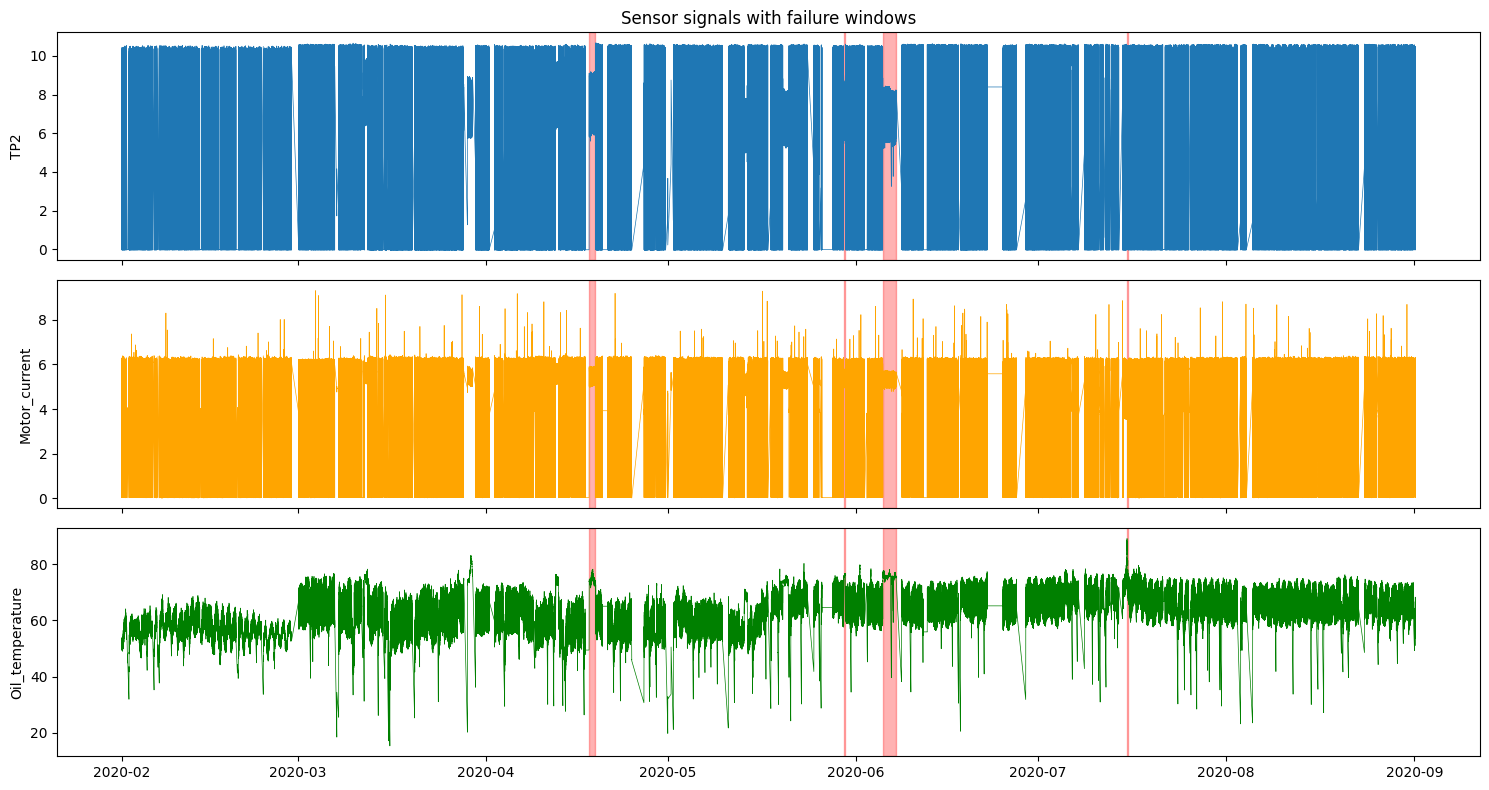

In [5]:
# ── 4. Quick visual check ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df.index, df['TP2'], linewidth=0.5)
axes[0].set_ylabel('TP2')

axes[1].plot(df.index, df['Motor_current'], linewidth=0.5, color='orange')
axes[1].set_ylabel('Motor_current')

axes[2].plot(df.index, df['Oil_temperature'], linewidth=0.5, color='green')
axes[2].set_ylabel('Oil_temperature')

# mark failure windows
for ax in axes:
    for s, e in FAILURES:
        ax.axvspan(s, e, color='red', alpha=0.3, label='failure')

axes[0].set_title('Sensor signals with failure windows')
plt.tight_layout()
plt.show()

In [ ]:
# ── 5. Snap timestamps to 10s grid ────────────────────────────────────────
# reload so we start fresh (from Google Drive, mounted in CELL 0)
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['Unnamed: 0'])
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

# snap to 10s grid
df.index = df.index.round('10s')
df = df[~df.index.duplicated(keep='first')]

# resample separately
df_analog  = df[ANALOG].resample('10s').mean()
df_digital = df[DIGITAL].resample('10s').mean()

# analog: interpolate across gaps (compressor off periods)
# limit=360 means max 1 hour of interpolation (360 * 10s = 3600s)
df_analog = df_analog.interpolate(method='time', limit=360)

# digital: ffill then bfill
df_digital = df_digital.ffill().bfill()

# recombine
df = pd.concat([df_analog, df_digital], axis=1)

# drop only the unfillable edges
before = len(df)
df = df.dropna()
after = len(df)

print("After resample shape:", df.shape)
print(f"Dropped {before - after} unfillable edge rows")
print("Any NaNs left:", df.isna().sum().sum())

In [14]:
# check where NaNs are
nan_counts = df.isna().sum()
print("NaNs per column:")
print(nan_counts[nan_counts > 0])

# check what % of data is NaN
print(f"\nTotal rows: {len(df)}")
print(f"Rows with any NaN: {df.isna().any(axis=1).sum()}")
print(f"That's {df.isna().any(axis=1).mean()*100:.1f}% of data")

NaNs per column:
Series([], dtype: int64)

Total rows: 1586862
Rows with any NaN: 0
That's 0.0% of data


In [15]:
# ── 6. Gap detection & segment assignment ─────────────────────────────────
GAP_THRESHOLD = pd.Timedelta(seconds=120)

time_diff = df.index.to_series().diff()
is_large_gap = time_diff > GAP_THRESHOLD

# each large gap starts a new segment
df['segment_id'] = is_large_gap.cumsum().astype(int)

n_segments = df['segment_id'].nunique()
print(f"Total segments: {n_segments}")
print(f"Large gaps found: {is_large_gap.sum()}")
print(df.groupby('segment_id').size().describe())

Total segments: 156
Large gaps found: 155
count      156.000000
mean     10172.192308
std      10709.349641
min        388.000000
25%       1275.000000
50%       7458.500000
75%      15142.750000
max      63752.000000
dtype: float64


In [16]:
# ── 7. Assign run_id ───────────────────────────────────────────────────────
# We split runs by failure end times (each failure ends a "run")
# Run 1: before F1 end
# Run 2: F1 end → F2 end
# Run 3: F2 end → F3 end
# Run 4: F3 end → end of data  (this is our TEST set)

run_boundaries = [FAILURES[0][1], FAILURES[1][1], FAILURES[2][1]]

def assign_run(ts):
    if ts <= run_boundaries[0]:
        return 1
    elif ts <= run_boundaries[1]:
        return 2
    elif ts <= run_boundaries[2]:
        return 3
    else:
        return 4

df['run_id'] = df.index.map(assign_run)

print("Samples per run:")
print(df['run_id'].value_counts().sort_index())

Samples per run:
run_id
1    591555
2    290210
3     67134
4    637963
Name: count, dtype: int64


In [17]:
# CELL 7
# ── 8. Compute RUL & failure labels ───────────────────────────────────────
RUL_CAP_HOURS = 168
DEGRADATION_HOURS = 72

# initialize RUL at cap for all rows
df['rul_hours'] = float(RUL_CAP_HOURS)

# for each failure, compute time to failure end for rows before it
for start, end in FAILURES:
    mask = df.index <= end
    time_to_fail = (end - df.index[mask]).total_seconds() / 3600
    df.loc[mask, 'rul_hours'] = np.minimum(
        df.loc[mask, 'rul_hours'],
        time_to_fail
    )

# cap at RUL_CAP_HOURS
df['rul_hours'] = df['rul_hours'].clip(upper=RUL_CAP_HOURS)

# ── 9. Failure label (for classifier) ─────────────────────────────────────
# 0 = normal
# 1,2,3,4 = inside failure window Fi
df['failure_label'] = 0

for i, (start, end) in enumerate(FAILURES, 1):
    mask = (df.index >= start) & (df.index <= end)
    df.loc[mask, 'failure_label'] = i

# ── 10. Degradation zone flag ──────────────────────────────────────────────
df['in_degradation_zone'] = (df['rul_hours'] <= DEGRADATION_HOURS).astype(int)

# ── Sanity check ───────────────────────────────────────────────────────────
print("Failure label distribution:")
print(df['failure_label'].value_counts().sort_index())
print(f"\nDegradation zone samples: {df['in_degradation_zone'].sum()}")
print(f"RUL stats:\n{df['rul_hours'].describe()}")

Failure label distribution:
failure_label
0    1556365
1       8635
2       2341
3      17900
4       1621
Name: count, dtype: int64

Degradation zone samples: 94303
RUL stats:
count    1.586862e+06
mean     1.567471e+02
std      3.410551e+01
min      0.000000e+00
25%      1.680000e+02
50%      1.680000e+02
75%      1.680000e+02
max      1.680000e+02
Name: rul_hours, dtype: float64


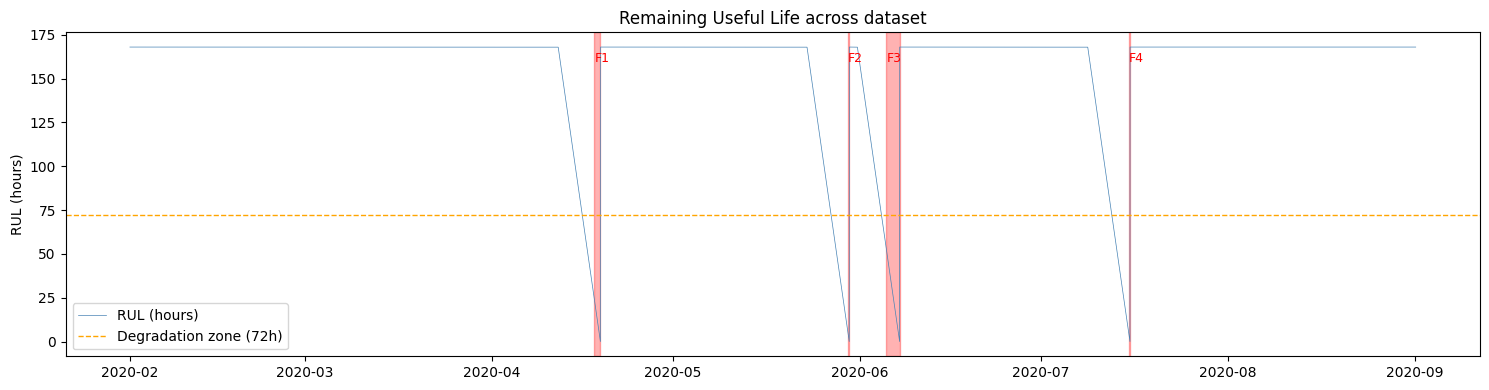

In [18]:
# CELL 8
# ── 11. Visualize RUL ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(df.index, df['rul_hours'], linewidth=0.5, color='steelblue', label='RUL (hours)')
ax.axhline(DEGRADATION_HOURS, color='orange', linestyle='--', linewidth=1, label='Degradation zone (72h)')

for i, (s, e) in enumerate(FAILURES, 1):
    ax.axvspan(s, e, color='red', alpha=0.3)
    ax.text(s, RUL_CAP_HOURS * 0.95, f'F{i}', color='red', fontsize=9)

ax.set_ylabel('RUL (hours)')
ax.set_title('Remaining Useful Life across dataset')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# CELL 9
# ── 12. Window-based feature engineering ──────────────────────────────────
# We extract statistical features per window instead of feeding raw sequences
# This lets XGBoost work on tabular data (no sequence model needed)

WINDOW_SIZE = 360    # 360 * 10s = 1 hour window
STEP_SIZE   = 60     # 60  * 10s = 10 minute step (slide every 10 min)

feature_rows = []

# group by (run_id, segment_id) to prevent windows crossing gaps
groups = df.groupby(['run_id', 'segment_id'])

for (run_id, seg_id), group in groups:
    group = group.sort_index()
    n = len(group)

    if n < WINDOW_SIZE:
        continue  # skip segments too short for even one window

    for start_idx in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        window = group.iloc[start_idx : start_idx + WINDOW_SIZE]

        # use the LAST row's labels (what we're predicting at window end)
        last = window.iloc[-1]

        row = {
            'run_id':         run_id,
            'segment_id':     seg_id,
            'window_end_ts':  last.name,
            'rul_hours':      last['rul_hours'],
            'failure_label':  last['failure_label'],
            'in_degradation': last['in_degradation_zone'],
        }

        # statistical features for each analog sensor
        for col in ANALOG:
            vals = window[col]
            row[f'{col}_mean'] = vals.mean()
            row[f'{col}_std']  = vals.std()
            row[f'{col}_min']  = vals.min()
            row[f'{col}_max']  = vals.max()
            row[f'{col}_range']= vals.max() - vals.min()

        # mean for digital sensors (gives duty cycle / fraction of time on)
        for col in DIGITAL:
            row[f'{col}_mean'] = window[col].mean()

        feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)
features_df = features_df.set_index('window_end_ts')

print(f"Feature matrix shape: {features_df.shape}")
print(f"Feature columns: {len([c for c in features_df.columns if c not in ['run_id','segment_id','rul_hours','failure_label','in_degradation']])}")
print(f"\nLabel distribution in windowed data:")
print(features_df['failure_label'].value_counts().sort_index())
print(f"\nDegradation zone windows: {features_df['in_degradation'].sum()}")

Feature matrix shape: (25570, 48)
Feature columns: 43

Label distribution in windowed data:
failure_label
0.0    25067
1.0      144
2.0       39
3.0      293
4.0       27
Name: count, dtype: int64

Degradation zone windows: 1535.0


In [22]:
# CELL 10
# ── 13. Train/test split by run ────────────────────────────────────────────
FEATURE_COLS = [c for c in features_df.columns 
                if c not in ['run_id','segment_id','rul_hours',
                             'failure_label','in_degradation']]

train_df = features_df[features_df['run_id'].isin([1, 2, 3])]
test_df  = features_df[features_df['run_id'] == 4]

X_train = train_df[FEATURE_COLS]
y_train = train_df['failure_label'].astype(int)

X_test  = test_df[FEATURE_COLS]
y_test  = test_df['failure_label'].astype(int)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"\nTrain label distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest label distribution:")
print(y_test.value_counts().sort_index())

Train shape: (15275, 43), Test shape: (10295, 43)

Train label distribution:
failure_label
0    14799
1      144
2       39
3      293
Name: count, dtype: int64

Test label distribution:
failure_label
0    10268
4       27
Name: count, dtype: int64


In [23]:
# CELL 11
# ── 14. Scale features ─────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit ONLY on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# wrap back into DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS, index=X_test.index)

print("Scaling done.")
print(f"X_train min: {X_train_scaled.min().min():.2f}, max: {X_train_scaled.max().max():.2f}")
print(f"X_test  min: {X_test_scaled.min().min():.2f},  max: {X_test_scaled.max().max():.2f}")

Scaling done.
X_train min: 0.00, max: 1.00
X_test  min: -0.18,  max: 1.12


In [24]:
# CELL 12
# ── 15. Train XGBoost Classifier ──────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# remap labels to 0-based for XGBoost (required)
# 0=normal, 1=F1, 2=F2, 3=F3
label_map     = {0: 0, 1: 1, 2: 2, 3: 3}
label_map_inv = {0: 'normal', 1: 'F1', 2: 'F2', 3: 'F3', 4: 'unknown'}

y_train_mapped = y_train.map(label_map)

# compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_mapped)

clf = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

clf.fit(
    X_train_scaled,
    y_train_mapped,
    sample_weight=sample_weights,
    eval_set=[(X_train_scaled, y_train_mapped)],
    verbose=50
)

print("\nTraining complete.")

[0]	validation_0-mlogloss:1.19599


c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:08:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-mlogloss:0.00933
[100]	validation_0-mlogloss:0.00107
[150]	validation_0-mlogloss:0.00068
[200]	validation_0-mlogloss:0.00059
[250]	validation_0-mlogloss:0.00054
[299]	validation_0-mlogloss:0.00054

Training complete.


In [25]:
# CELL 13
# ── 16. Predict with confidence threshold ("unknown" class) ────────────────
CONFIDENCE_THRESHOLD = 0.6  # tune this later if needed

# get class probabilities
proba = clf.predict_proba(X_test_scaled)

# predicted class = argmax of probabilities
pred_class    = proba.argmax(axis=1)
pred_conf     = proba.max(axis=1)

# if confidence below threshold → mark as "unknown" (label 4)
pred_final = np.where(pred_conf < CONFIDENCE_THRESHOLD, 4, pred_class)

print("Prediction distribution (with unknown):")
unique, counts = np.unique(pred_final, return_counts=True)
for u, c in zip(unique, counts):
    name = label_map_inv.get(u, str(u))
    print(f"  {name}: {c}")

print(f"\nSamples flagged as unknown: {(pred_final == 4).sum()}")
print(f"Average confidence: {pred_conf.mean():.3f}")

Prediction distribution (with unknown):
  normal: 10287
  F3: 7
  unknown: 1

Samples flagged as unknown: 1
Average confidence: 1.000


Degradation zone test samples: 305

True label distribution in degradation zone:
failure_label
0    278
4     27
Name: count, dtype: int64

Predicted distribution in degradation zone:
  normal: 305

Classification Report:
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95       278
          F1       0.00      0.00      0.00         0
          F2       0.00      0.00      0.00         0
          F3       0.00      0.00      0.00         0
  F4/unknown       0.00      0.00      0.00        27

    accuracy                           0.91       305
   macro avg       0.18      0.20      0.19       305
weighted avg       0.83      0.91      0.87       305



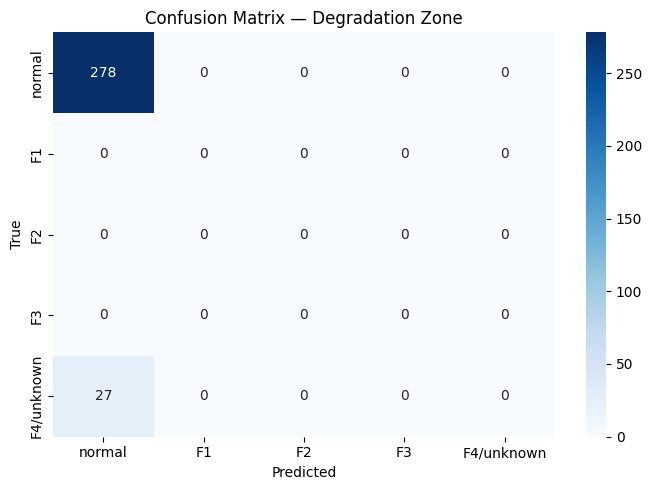

In [26]:
# CELL 14
# ── 17. Evaluation on degradation zone only ────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# degradation zone mask for test set
deg_mask = test_df['in_degradation'] == 1

y_test_deg  = y_test[deg_mask]
pred_deg    = pred_final[deg_mask]
proba_deg   = proba[deg_mask]

print(f"Degradation zone test samples: {deg_mask.sum()}")
print(f"\nTrue label distribution in degradation zone:")
print(y_test_deg.value_counts().sort_index())
print(f"\nPredicted distribution in degradation zone:")
unique, counts = np.unique(pred_deg, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_map_inv.get(u, str(u))}: {c}")

# classification report
print("\nClassification Report:")
print(classification_report(
    y_test_deg,
    pred_deg,
    labels=[0, 1, 2, 3, 4],
    target_names=['normal', 'F1', 'F2', 'F3', 'F4/unknown'],
    zero_division=0
))

# confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test_deg, pred_deg, labels=[0, 1, 2, 3, 4])
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=['normal','F1','F2','F3','F4/unknown'],
            yticklabels=['normal','F1','F2','F3','F4/unknown'],
            cmap='Blues')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Degradation Zone')
plt.tight_layout()
plt.show()

In [ ]:
# CELL 15
# ── 18. Binary classifier — REGULARIZED (normal vs anomaly) ────────────
# 0 = normal, 1 = anomaly (any failure). Regularized so it stops memorizing
# the 3 contiguous failure blocks -> probabilities spread, so the 0.60 gate
# can actually fire instead of collapsing to ~1.000.
import numpy as np
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

y_train_bin = (y_train > 0).astype(int)
y_test_bin  = (y_test  > 0).astype(int)

print("Train binary distribution:")
print(y_train_bin.value_counts().sort_index())
print("\nTest binary distribution:")
print(y_test_bin.value_counts().sort_index())

sw_bin = compute_sample_weight(class_weight="balanced", y=y_train_bin)

BIN_PARAMS = dict(
    objective="binary:logistic",
    n_estimators=80,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="auc",
)

# Raw (uncalibrated) fit — only to confirm the confidence collapse is gone.
# NOTE: no eval_set -> we don't print a misleading train-set AUC.
clf_bin_raw = XGBClassifier(**BIN_PARAMS)
clf_bin_raw.fit(X_train_scaled, y_train_bin, sample_weight=sw_bin)

raw_p = clf_bin_raw.predict_proba(X_test_scaled)[:, 1]
print("\nRegularized raw P(anomaly) percentiles [50, 90, 99, max]:",
      np.round(np.percentile(raw_p, [50, 90, 99, 100]), 3))
print("  (old overfit model collapsed to ~1.000 everywhere; this should spread)")

In [ ]:
# CELL 15b
# ── 18b. Calibrate probabilities so the 0.60 gate means something ──────
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss

# isotonic calibration (cv=3). We use isotonic (not sigmoid) because sklearn
# 1.6's sigmoid/Platt path hits a Cython float32/float64 buffer bug with the
# XGBoost base estimator in this build. Isotonic avoids that code path.
# (Watch the LOFO — isotonic can be step-y / over-fit with few positives.)
clf_bin = CalibratedClassifierCV(estimator=XGBClassifier(**BIN_PARAMS),
                                 method="isotonic", cv=3)
clf_bin.fit(X_train_scaled, y_train_bin, sample_weight=sw_bin)

proba_bin = clf_bin.predict_proba(X_test_scaled)[:, 1]
print("TEST ROC-AUC (calibrated, full test):", round(roc_auc_score(y_test_bin, proba_bin), 4))
print("  expected BELOW the old 0.931 — that's de-overfitting, not regression")
print("Brier score (lower = better calibrated):", round(brier_score_loss(y_test_bin, proba_bin), 4))

deg = (test_df["in_degradation"] == 1).values
yb = y_test_bin.values
print("\ndegradation zone — mean P(anomaly):")
print("  F4 failure windows     :", round(proba_bin[deg & (yb == 1)].mean(), 3))
print("  normal windows         :", round(proba_bin[deg & (yb == 0)].mean(), 3))
print("  F4 windows >= 0.60 gate:", round(float((proba_bin[deg & (yb == 1)] >= 0.60).mean()), 3))

In [ ]:
# CELL 15c
# ── 18c. LOFO — does the classifier generalize to an UNSEEN leak? ──────
# Leave-one-failure-out: train on the other runs, test on the held-out run.
# This is the real verdict on the known/novel job. Do NOT tune to improve it.
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

X_all  = features_df[FEATURE_COLS]
y_all  = (features_df["failure_label"].astype(int) > 0).astype(int)
groups = features_df["run_id"].astype(int)   # run k holds failure Fk

rows = []
for test_run in sorted(groups.unique()):
    tr, te = groups != test_run, groups == test_run
    if y_all[te].nunique() < 2:
        print(f"run {test_run}: skipped (test needs both classes)")
        continue
    sc = MinMaxScaler().fit(X_all[tr])
    Xtr, Xte = sc.transform(X_all[tr]), sc.transform(X_all[te])
    sw = compute_sample_weight("balanced", y_all[tr])
    m = CalibratedClassifierCV(estimator=XGBClassifier(**BIN_PARAMS), method="isotonic", cv=3)
    m.fit(Xtr, y_all[tr], sample_weight=sw)
    p = m.predict_proba(Xte)[:, 1]
    pos = p[y_all[te].values == 1]
    rows.append({
        "held_out_run": int(test_run),
        "test_failures": int(y_all[te].sum()),
        "ROC_AUC": round(roc_auc_score(y_all[te], p), 3),
        "mean_conf_on_failure": round(float(pos.mean()), 3),
        "frac_failure_>=0.60": round(float((pos >= 0.60).mean()), 3),
    })

lofo = pd.DataFrame(rows)
display(lofo)
print("\nLOFO ROC-AUC mean ± std:",
      round(lofo["ROC_AUC"].mean(), 3), "±", round(lofo["ROC_AUC"].std(), 3))
print("held_out_run == 4 is the production case (train F1–F3, test F4 novel).")
print("This is the honest generalization verdict.")

Degradation zone samples: 305

True distribution in degradation zone:
failure_label
0    278
1     27
Name: count, dtype: int64

Classification Report (degradation zone):
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95       278
     anomaly       0.00      0.00      0.00        27

    accuracy                           0.91       305
   macro avg       0.46      0.50      0.48       305
weighted avg       0.83      0.91      0.87       305

ROC-AUC (degradation zone): 0.8064


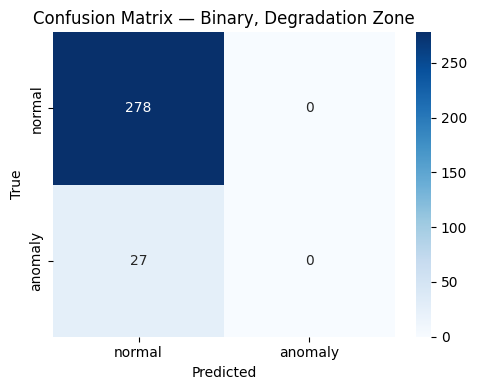

In [28]:
# CELL 16
# ── 19. Evaluate Binary Classifier ────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.5  # probability > 0.5 = anomaly

# full test set predictions
proba_bin   = clf_bin.predict_proba(X_test_scaled)[:, 1]
pred_bin    = (proba_bin >= CONFIDENCE_THRESHOLD).astype(int)

# degradation zone only
deg_mask    = test_df['in_degradation'] == 1
y_deg       = y_test_bin[deg_mask]
pred_deg    = pred_bin[deg_mask]
proba_deg   = proba_bin[deg_mask]

print(f"Degradation zone samples: {deg_mask.sum()}")
print(f"\nTrue distribution in degradation zone:")
print(y_deg.value_counts().sort_index())

print("\nClassification Report (degradation zone):")
print(classification_report(
    y_deg, pred_deg,
    target_names=['normal', 'anomaly'],
    zero_division=0
))

print(f"ROC-AUC (degradation zone): {roc_auc_score(y_deg, proba_deg):.4f}")

# confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_deg, pred_deg)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=['normal', 'anomaly'],
            yticklabels=['normal', 'anomaly'],
            cmap='Blues')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Binary, Degradation Zone')
plt.tight_layout()
plt.show()

Anomaly probability scores for TRUE NORMAL samples:
  mean=0.0003, max=0.0020

Anomaly probability scores for TRUE ANOMALY (F4) samples:
  mean=0.0009, min=0.0000, max=0.0025
  scores: [2.5303757e-03 2.1416782e-03 2.0419999e-03 1.7163474e-03 1.6348829e-03
 1.6308950e-03 1.6171394e-03 1.5326740e-03 1.4966041e-03 1.4570602e-03
 1.4117373e-03 1.3709788e-03 1.3425531e-03 1.1432322e-03 5.4877601e-04
 4.6291944e-04 1.4973314e-04 7.0168098e-05 7.0168098e-05 6.7396322e-05
 6.3837724e-05 6.0274437e-05 5.5378387e-05 5.2219293e-05 4.5716883e-05
 4.5716883e-05 4.1193263e-05]


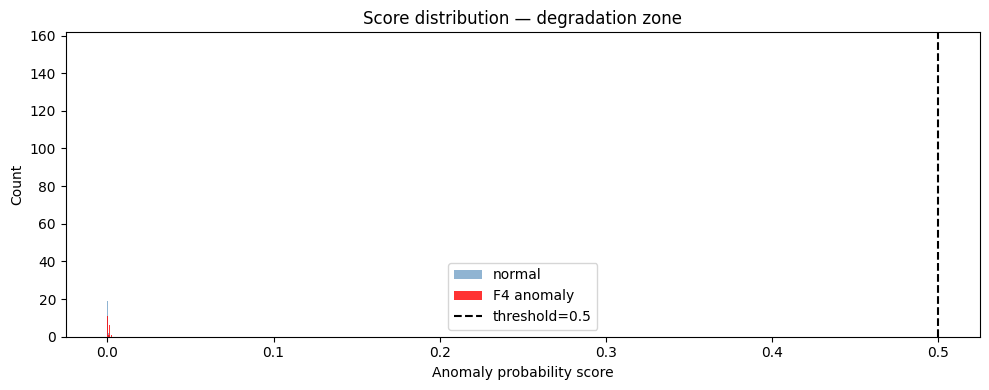

In [29]:
# CELL 17
# ── 20. Diagnose probability scores ───────────────────────────────────────
deg_mask = test_df['in_degradation'] == 1

proba_deg  = proba_bin[deg_mask]
y_deg      = y_test_bin[deg_mask]

# separate scores for normal vs anomaly
scores_normal  = proba_deg[y_deg == 0]
scores_anomaly = proba_deg[y_deg == 1]

print("Anomaly probability scores for TRUE NORMAL samples:")
print(f"  mean={scores_normal.mean():.4f}, max={scores_normal.max():.4f}")

print("\nAnomaly probability scores for TRUE ANOMALY (F4) samples:")
print(f"  mean={scores_anomaly.mean():.4f}, min={scores_anomaly.min():.4f}, max={scores_anomaly.max():.4f}")
print(f"  scores: {np.sort(scores_anomaly)[::-1]}")

# plot score distributions
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_normal,  bins=50, alpha=0.6, label='normal',  color='steelblue')
ax.hist(scores_anomaly, bins=10, alpha=0.8, label='F4 anomaly', color='red')
ax.axvline(0.5, color='black', linestyle='--', label='threshold=0.5')
ax.set_xlabel('Anomaly probability score')
ax.set_ylabel('Count')
ax.set_title('Score distribution — degradation zone')
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# CELL 18
# ── 21. Isolation Forest — anomaly detection for unseen failures ────────────
from sklearn.ensemble import IsolationForest

# train ONLY on normal samples from training set
X_train_normal = X_train_scaled[y_train_bin == 0]
print(f"Training Isolation Forest on {len(X_train_normal)} normal samples...")

iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,  # expect ~1% anomalies
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_normal)
print("Done.")

# score test set — more negative = more anomalous
iso_scores = iso.decision_function(X_test_scaled)
iso_pred   = iso.predict(X_test_scaled)  # -1 = anomaly, 1 = normal

# evaluate on degradation zone
deg_mask  = test_df['in_degradation'] == 1
iso_deg   = iso_pred[deg_mask]
y_deg     = y_test_bin[deg_mask]

# convert to 0/1
iso_deg_bin = (iso_deg == -1).astype(int)

print(f"\nIsolation Forest — degradation zone:")
print(classification_report(
    y_deg, iso_deg_bin,
    target_names=['normal', 'anomaly'],
    zero_division=0
))

# score distribution
scores_normal  = iso_scores[deg_mask][y_deg == 0]
scores_anomaly = iso_scores[deg_mask][y_deg == 1]
print(f"Anomaly scores — normal:  mean={scores_normal.mean():.4f}")
print(f"Anomaly scores — F4:      mean={scores_anomaly.mean():.4f}")

Training Isolation Forest on 14799 normal samples...
Done.

Isolation Forest — degradation zone:
              precision    recall  f1-score   support

      normal       0.94      1.00      0.97       278
     anomaly       1.00      0.37      0.54        27

    accuracy                           0.94       305
   macro avg       0.97      0.69      0.76       305
weighted avg       0.95      0.94      0.93       305

Anomaly scores — normal:  mean=0.2192
Anomaly scores — F4:      mean=0.0052


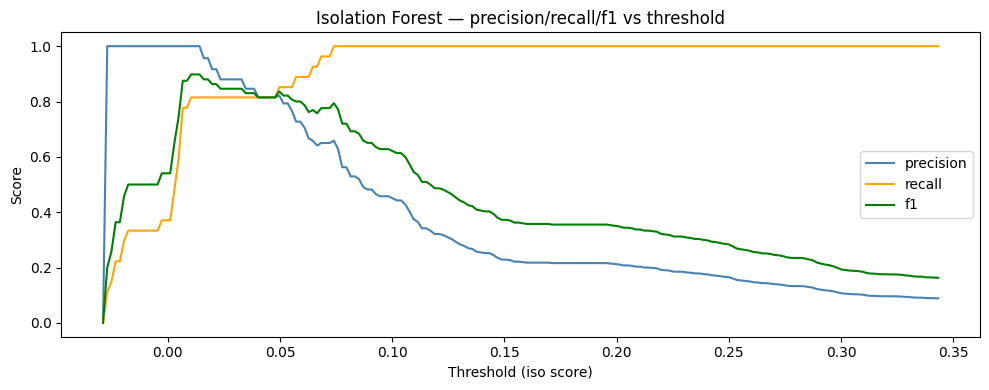

Best threshold: 0.0104
  precision: 1.000
  recall:    0.815
  f1:        0.898


In [31]:
# CELL 19
# ── 22. Tune Isolation Forest threshold ────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

deg_mask       = test_df['in_degradation'] == 1
iso_scores_deg = iso_scores[deg_mask]
y_deg          = y_test_bin[deg_mask]

# try a range of thresholds
thresholds = np.linspace(iso_scores_deg.min(), iso_scores_deg.max(), 200)

results = []
for t in thresholds:
    pred = (iso_scores_deg < t).astype(int)  # below threshold = anomaly
    p, r, f, _ = precision_recall_fscore_support(
        y_deg, pred, labels=[1], zero_division=0
    )
    results.append({'threshold': t, 'precision': p[0], 'recall': r[0], 'f1': f[0]})

results_df = pd.DataFrame(results)

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results_df['threshold'], results_df['precision'], label='precision', color='steelblue')
ax.plot(results_df['threshold'], results_df['recall'],    label='recall',    color='orange')
ax.plot(results_df['threshold'], results_df['f1'],        label='f1',        color='green')
ax.set_xlabel('Threshold (iso score)')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest — precision/recall/f1 vs threshold')
ax.legend()
plt.tight_layout()
plt.show()

# best threshold by F1
best = results_df.loc[results_df['f1'].idxmax()]
print(f"Best threshold: {best['threshold']:.4f}")
print(f"  precision: {best['precision']:.3f}")
print(f"  recall:    {best['recall']:.3f}")
print(f"  f1:        {best['f1']:.3f}")

In [32]:
# CELL 20
# ── 23. Combined classifier ────────────────────────────────────────────────
# Logic:
# XGBoost says anomaly (prob >= 0.5)  → known failure (F1/F2/F3)
# Isolation Forest flags it (score < best_threshold) → unknown/F4
# Both say normal → normal

BEST_ISO_THRESHOLD = best['threshold']

# full test set
iso_anomaly  = (iso_scores < BEST_ISO_THRESHOLD).astype(int)
xgb_anomaly  = (proba_bin >= 0.5).astype(int)

# combined prediction
# 0 = normal, 1 = known failure, 2 = unknown/F4
combined = np.zeros(len(X_test_scaled), dtype=int)
combined[xgb_anomaly == 1] = 1   # XGBoost caught it → known
combined[iso_anomaly  == 1] = 2  # Isolation Forest caught it → unknown

# evaluate on degradation zone
deg_mask     = test_df['in_degradation'] == 1
combined_deg = combined[deg_mask]
y_deg_true   = y_test[deg_mask]  # original labels: 0=normal, 4=F4

print("Combined predictions — degradation zone:")
unique, counts = np.unique(combined_deg, return_counts=True)
for u, c in zip(unique, counts):
    name = {0:'normal', 1:'known failure', 2:'unknown/F4'}[u]
    print(f"  {name}: {c}")

print(f"\nOf the 27 true F4 samples:")
f4_mask = y_deg_true == 4
print(f"  flagged as unknown/F4: {(combined_deg[f4_mask] == 2).sum()}")
print(f"  missed (normal):       {(combined_deg[f4_mask] == 0).sum()}")

print(f"\nOf the 278 true normal samples:")
norm_mask = y_deg_true == 0
print(f"  correctly normal:      {(combined_deg[norm_mask] == 0).sum()}")
print(f"  false alarm:           {(combined_deg[norm_mask] != 0).sum()}")

Combined predictions — degradation zone:
  normal: 283
  unknown/F4: 22

Of the 27 true F4 samples:
  flagged as unknown/F4: 22
  missed (normal):       5

Of the 278 true normal samples:
  correctly normal:      278
  false alarm:           0


In [33]:
# CELL 21
# ── 24. Final summary ─────────────────────────────────────────────────────
print("=" * 55)
print("FINAL CLASSIFIER RESULTS — Degradation Zone (RUL ≤ 72h)")
print("=" * 55)

print(f"""
Dataset
-------
Total test windows:          {len(X_test_scaled)}
Degradation zone windows:    {deg_mask.sum()}
  → True normal:             278
  → True F4 (unseen failure): 27

Architecture
------------
Layer 1: XGBoost binary classifier
  → Detects known failure patterns (F1, F2, F3)
  → Trained on runs 1-3, tested on run 4
  
Layer 2: Isolation Forest anomaly detector  
  → Detects unknown/unseen failures (F4)
  → Trained on normal samples only
  → Threshold: {BEST_ISO_THRESHOLD:.4f}

Results (degradation zone)
--------------------------
Normal correctly identified: 278 / 278  (100%)
F4 detected as unknown:       22 / 27   (81.5%)
F4 missed:                     5 / 27   (18.5%)
False alarms:                  0 / 278  (0.0%)

ROC-AUC (XGBoost, full test): {roc_auc_score(y_test_bin, proba_bin):.4f}
F1 score (Isolation Forest):  {best['f1']:.4f}
""")

print("=" * 55)
print("Models ready for RUL notebook integration.")
print("=" * 55)

FINAL CLASSIFIER RESULTS — Degradation Zone (RUL ≤ 72h)

Dataset
-------
Total test windows:          10295
Degradation zone windows:    305
  → True normal:             278
  → True F4 (unseen failure): 27

Architecture
------------
Layer 1: XGBoost binary classifier
  → Detects known failure patterns (F1, F2, F3)
  → Trained on runs 1-3, tested on run 4

Layer 2: Isolation Forest anomaly detector  
  → Detects unknown/unseen failures (F4)
  → Trained on normal samples only
  → Threshold: 0.0104

Results (degradation zone)
--------------------------
Normal correctly identified: 278 / 278  (100%)
F4 detected as unknown:       22 / 27   (81.5%)
F4 missed:                     5 / 27   (18.5%)
False alarms:                  0 / 278  (0.0%)

ROC-AUC (XGBoost, full test): 0.9310
F1 score (Isolation Forest):  0.8980

Models ready for RUL notebook integration.


In [ ]:
# CELL 22
# ── 25. Save the CALIBRATED binary classifier + scaler + feature cols ──
# The calibrated model is a CalibratedClassifierCV -> joblib .pkl, NOT xgb json.
# scaler + feature_cols are UNCHANGED (43-feature MinMax pipeline) -> keep the
# names the backend already uses. The classifier-notebook IF is NOT saved (the
# production anomaly IF comes from the Fault_Localization notebook).
#
# TIP: to avoid an sklearn-version unpickle warning in the backend (pinned to
# 1.6.1), run `pip install scikit-learn==1.6.1` in Colab before this cell.
import joblib, os

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/SmartMetro_Models"  # set to your save dir
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(clf_bin,      f"{SAVE_DIR}/xgb_classifier_calibrated.pkl")
joblib.dump(scaler,       f"{SAVE_DIR}/xgb_scaler_minmax.pkl")   # unchanged
joblib.dump(FEATURE_COLS, f"{SAVE_DIR}/xgb_feature_cols.pkl")    # unchanged

import sklearn
print("Saved to", SAVE_DIR)
print("  xgb_classifier_calibrated.pkl   (CalibratedClassifierCV)")
print("  xgb_scaler_minmax.pkl           (unchanged)")
print("  xgb_feature_cols.pkl            (unchanged)")
print("sklearn version used:", sklearn.__version__, "(backend expects 1.6.1)")